<h1 style='color:red'>most_frequent value Imputation</h1>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
487,TA,TA,175000
106,NaN,Fa,100000
555,Gd,TA,113000
883,NaN,TA,118500
383,NaN,Fa,76000


In [4]:
df.isnull().mean()*100   
# 'FireplaceQu' has approx 47% missing values and 'GarageQual' has approx 5.5% missing values

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<h2 style='color:purple'>Analysing Garage Quality column </h2>

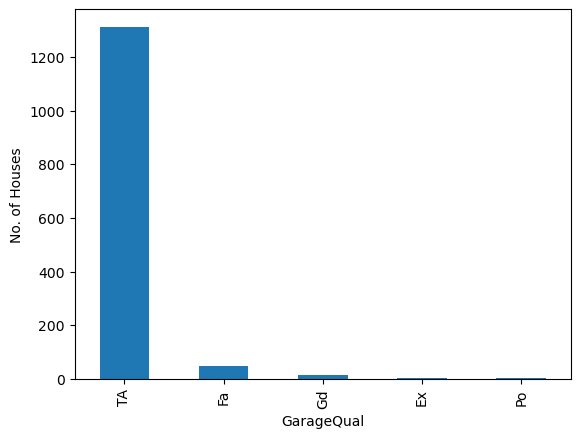

In [5]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind='bar')     
pyplot.xlabel('GarageQual')
pyplot.ylabel('No. of Houses')
pyplot.show()

# there are some missing values also, which is not shown in barplot

In [6]:
df['GarageQual'].mode()     # most frequent category in GarageQual

0    TA
Name: GarageQual, dtype: object

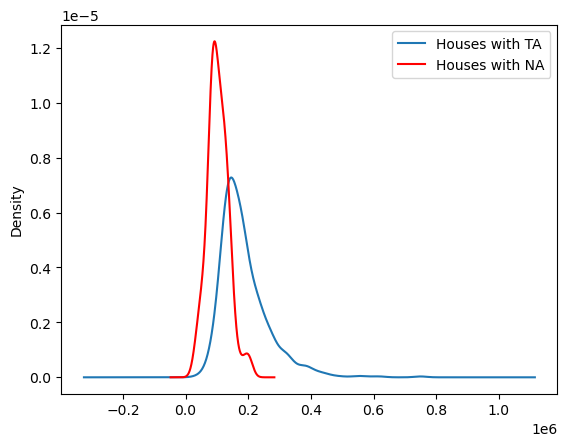

In [7]:
# kde plot of SalePrice
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', label='Houses with TA')                # kde plot where GarageQual='TA'
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', color='red', label='Houses with NA')  # kde plot where GarageQual='null'
pyplot.legend()
pyplot.show()

In [8]:
# storing the original 'TA' values data 
original_SalePrice_TA = df[df['GarageQual'] == 'TA']['SalePrice']

<h4 style='color:gold'>Pandas fillna() function </h4>

In [9]:
# imputing Missing Values with most_frequent == 'TA'
df['GarageQual'] = df['GarageQual'].fillna('TA')

<Axes: xlabel='GarageQual'>

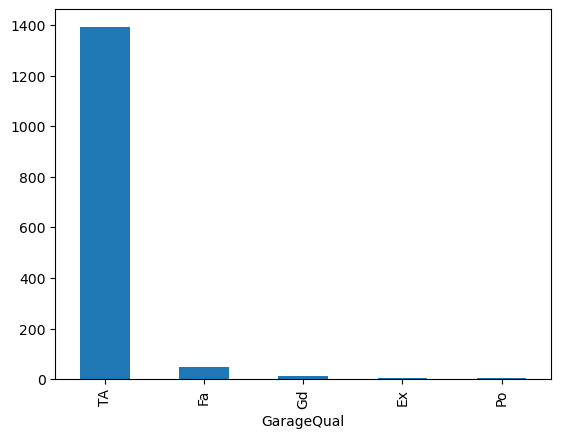

In [10]:
df['GarageQual'].value_counts().plot(kind='bar')

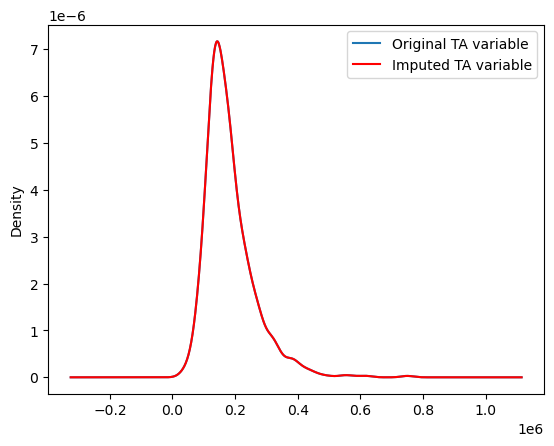

In [14]:
original_SalePrice_TA.plot(kind='kde')                             # distribution of the original 'TA' variable 

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', color='red')  # distribution of the 'TA' variable after imputation

labels = ['Original TA variable', 'Imputed TA variable']
pyplot.legend(labels)
pyplot.show()
# missing values was less, so no major change can be seen in kde plot of SalePrice for GarageQual='TA' in original and imputed one.

<h2 style='color:purple'>Analysing Fireplace Quality column </h2>

<Axes: xlabel='FireplaceQu'>

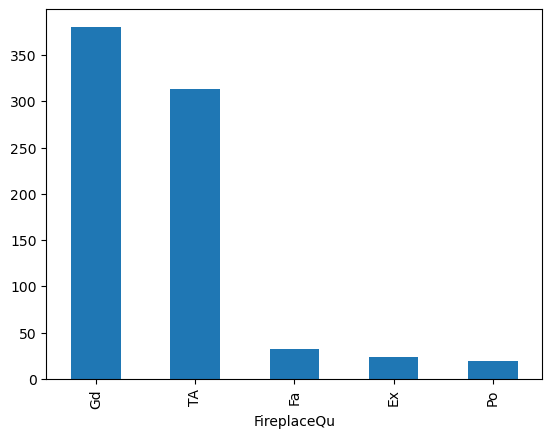

In [15]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot(kind='bar')    
# here we can see that the most_frequent category is not much dominating, which is not a favourable condition.
# as bcz there is no such major domination, imputing values by MODE will affect give expected results.

In [16]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

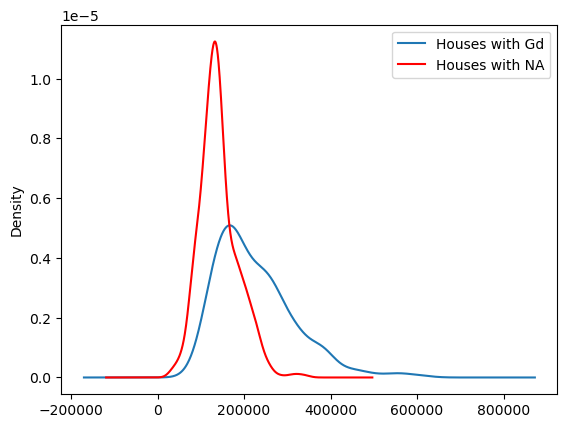

In [17]:
# kde plot of SalePrice
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', label='Houses with Gd')         # kde plot where GarageQual='Gd'(mode value)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', color='red', label='Houses with NA')  # kde plot where GarageQual='null'
pyplot.legend()
pyplot.show()

In [18]:
# storing the original 'TA' values data 
original_SalePrice_Gd = df[df['FireplaceQu'] == 'Gd']['SalePrice']

<h4 style='color:gold'>Pandas fillna() function </h4>

In [21]:
# imputing Missing Values with most_frequent == 'TA'
df['FireplaceQu'] = df['FireplaceQu'].fillna('Gd')          # Fireplace Quality has approx 47% missing values

<Axes: xlabel='FireplaceQu'>

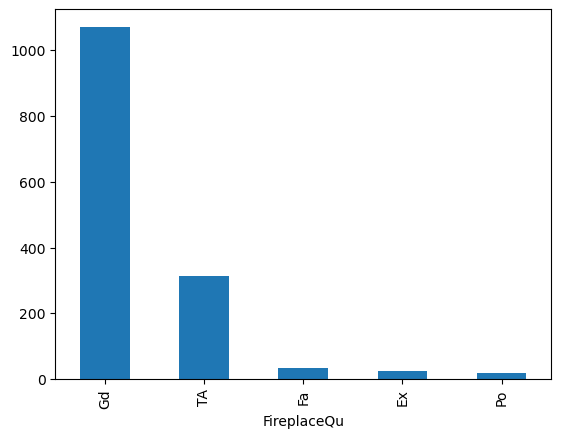

In [22]:
df['FireplaceQu'].value_counts().plot(kind='bar')

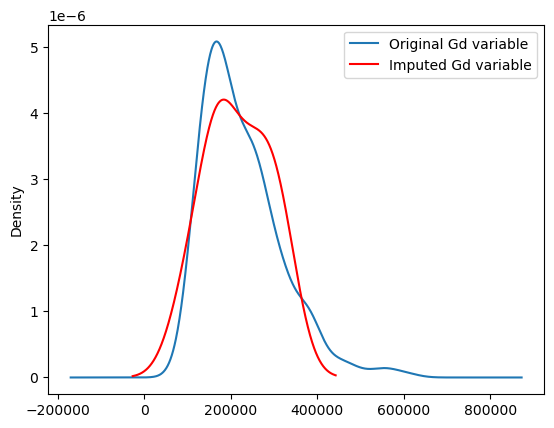

In [25]:
original_SalePrice_Gd.plot(kind='kde')                             # distribution of the original 'Gd' variable 

df[df['GarageQual'] == 'Gd']['SalePrice'].plot(kind='kde', color='red')  # distribution of the 'Gd' variable after imputation

labels = ['Original Gd variable', 'Imputed Gd variable']
pyplot.legend(labels)
pyplot.show()
# missing values are more, so the distribution in kde plot of SalePrice for FireplaceQu='Gd' in original and imputed one is quie different.

# we don't prefer this imputation in this column bcz of too much missing value and do not have a dominating MODE value.
# FireplaceQu -> frequent value Imputation ❌

<h2 style="color:purple">Applying SimpleImputer of sklearn</h2>

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['SalePrice'], test_size=0.25, random_state=0) 
X_train.shape, X_test.shape

((1095, 2), (365, 2))

In [27]:
imputer = SimpleImputer(strategy='most_frequent')

X_train_imp = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [30]:
imputer.statistics_     

# Mode for 'FireplaceQu' -> 'Gd'    (1st column)
# Mode for 'GarageQual' -> 'TA'

array(['Gd', 'TA'], dtype=object)